In [48]:
import numpy as np
import matplotlib.pyplot as plt

In [55]:
N: int = 32
tMax: int = 1000000
max_iters: int = 10

DIRS: np.ndarray = np.array([[0, 1], [0, -1], [1, 0], [-1, 0]])
S: np.ndarray = np.ones((N, N))
J: float = 1.
H: float = 0.
mu: float = 1.
kB: float = 1.
T: float = 10.

In [50]:
def GetDeltaEnergy(i: int, j: int) -> float:
    """Computes the change in energy of altering a single spin state in S at location (x, y)."""
    SC: float = 0.

    for k in DIRS:
        di: int = i + k[0]
        dj: int = j + k[1]

        # Periodic boundaries
        if di >= N:
            di -= N
        if dj >= N:
            dj -= N

        SC += S[i, j] * S[di, dj]

    return -0.5 * J * SC - mu * H * S[i, j]


def GetTotalEnergy() -> float:
    """Computes the total energy of a grid of spin states S according to the ising model."""
    energy: float = 0.

    for i in range(N):
        for j in range(N):
            energy += GetDeltaEnergy(i, j)

    return energy


def FlipState(i, j) -> None:
    """Flips the spin state at a randomized site."""
    S[i, j] = -1 * S[i, j]


def PlotState() -> None:
    """Plots the spin states of the magnetic substance."""
    plt.imshow(S)
    plt.show()

start energy: -2048.0
final energy: -100.000.
start energy: -2048.0
final energy: -36.000.
start energy: -2048.0
final energy: -20.000.
start energy: -2048.0
final energy: -28.000.
start energy: -2048.0
final energy: -52.000.
start energy: -2048.0
final energy: -8.000.
start energy: -2048.0
final energy: 16.000.
start energy: -2048.0
final energy: -40.000.
start energy: -2048.0
final energy: 44.000.
start energy: -2048.0
final energy: -8.000.


(0.0, 278.25)

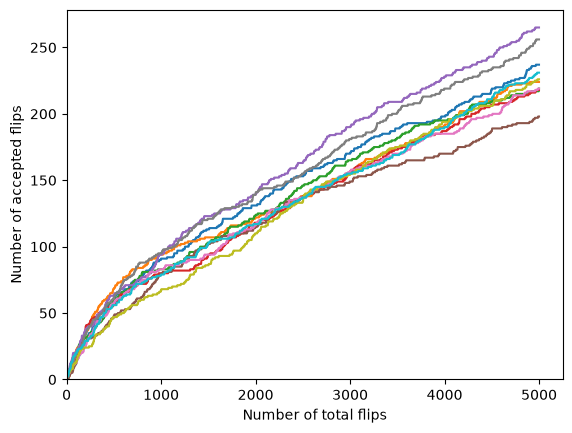

In [59]:
for i in range(max_iters):
    N: int = 32
    tMax: int = 5000
    max_iters: int = 10

    DIRS: np.ndarray = np.array([[0, 1], [0, -1], [1, 0], [-1, 0]])
    S: np.ndarray = np.ones((N, N))
    J: float = 1.
    H: float = 0.
    mu: float = 1.
    kB: float = 1.
    T: float = 10.

    E: float = GetTotalEnergy()
    print(f"start energy: {E}")


    flipped_counter = np.zeros(tMax)
    for t in range(tMax):
        x, y = np.random.randint(0, N), np.random.randint(0, N)
        FlipState(x, y)
        dE: float = GetDeltaEnergy(x, y)

        a: float = np.random.rand()
        w: float = min(1, np.exp(-dE / (kB * T)))

        if a <= w:
            continue
        else:
            FlipState(x, y)
            flipped_counter[t]=1

    E: float = GetTotalEnergy()
    plt.plot(np.cumsum(flipped_counter))
    print(f"final energy: {E:.3f}.")
    # i += 1

plt.xlabel('Number of total flips')
plt.ylabel('Number of accepted flips')
plt.xlim(left=0)
plt.ylim(bottom=0)

In [52]:


# PlotState()